# 01 — Exploratory Data Analysis

Load the data
The three questions EDA answers:
1. **Is the data trustworthy?** — missing values, duplicates, impossible values
2. **What shape is it?** — distributions, skew, outliers
3. **What relates to what?** — correlations, and the surprises hiding inside them

In [19]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))   # [so `from src...` works from notebooks/]

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from src.config import *
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", 40)

## Step 2 — Load and inspect

In [20]:
from src.data_prep import load_raw

df = load_raw()
print("Shape:", df.shape)
display(df.head())
print(df.dtypes)

Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


In [21]:
display(df.describe().T.round(2))
print("\nCategoricals:")
for col in CATEGORICAL:
    print(f"  {col:<8} {df[col].nunique()} levels: {sorted(df[col].unique())}")

,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.80,0.47,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.75,1.43,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.46,2.23,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.80,3989.44,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.73,1.12,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.73,1.14,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.54,0.71,0.0,2.91,3.53,4.04,31.80



Categoricals:
  cut      5 levels: ['Fair', 'Good', 'Ideal', 'Premium', 'Very Good']
  color    7 levels: ['D', 'E', 'F', 'G', 'H', 'I', 'J']
  clarity  8 levels: ['I1', 'IF', 'SI1', 'SI2', 'VS1', 'VS2', 'VVS1', 'VVS2']


## Step 3 — Data quality

`isna()` finds *declared* missing values. It does not find a **zero-millimetre diamond**.
Always check numeric ranges against physical reality — some missing data arrives disguised as 0.

In [22]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

zero_dim = df[(df["x"] == 0) | (df["y"] == 0) | (df["z"] == 0)]
print(f"\nRows with a zero dimension: {len(zero_dim)}   <- physically impossible")
display(zero_dim.head())

print("\nDimension ranges (look for the absurd):")
display(df[["x", "y", "z", "depth", "table"]].describe().loc[["min", "max"]].T)

Missing values: 0
Duplicate rows: 146

Rows with a zero dimension: 20   <- physically impossible


,carat,cut,color,clarity,depth,table,price,x,y,z
2207,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2314,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4791,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5471,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10167,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0



Dimension ranges (look for the absurd):


,min,max
x,0.0,10.74
y,0.0,58.90
z,0.0,31.80
depth,43.0,79.00
table,43.0,95.00


Note `y` max around 58 mm and `z` max around 31 mm. A 58 mm diamond would be the size of a
fist — and these rows carry ordinary prices. **Data-entry errors.** A handful of rows like
this is enough to visibly tilt a regression line, so they go.

## Distributions

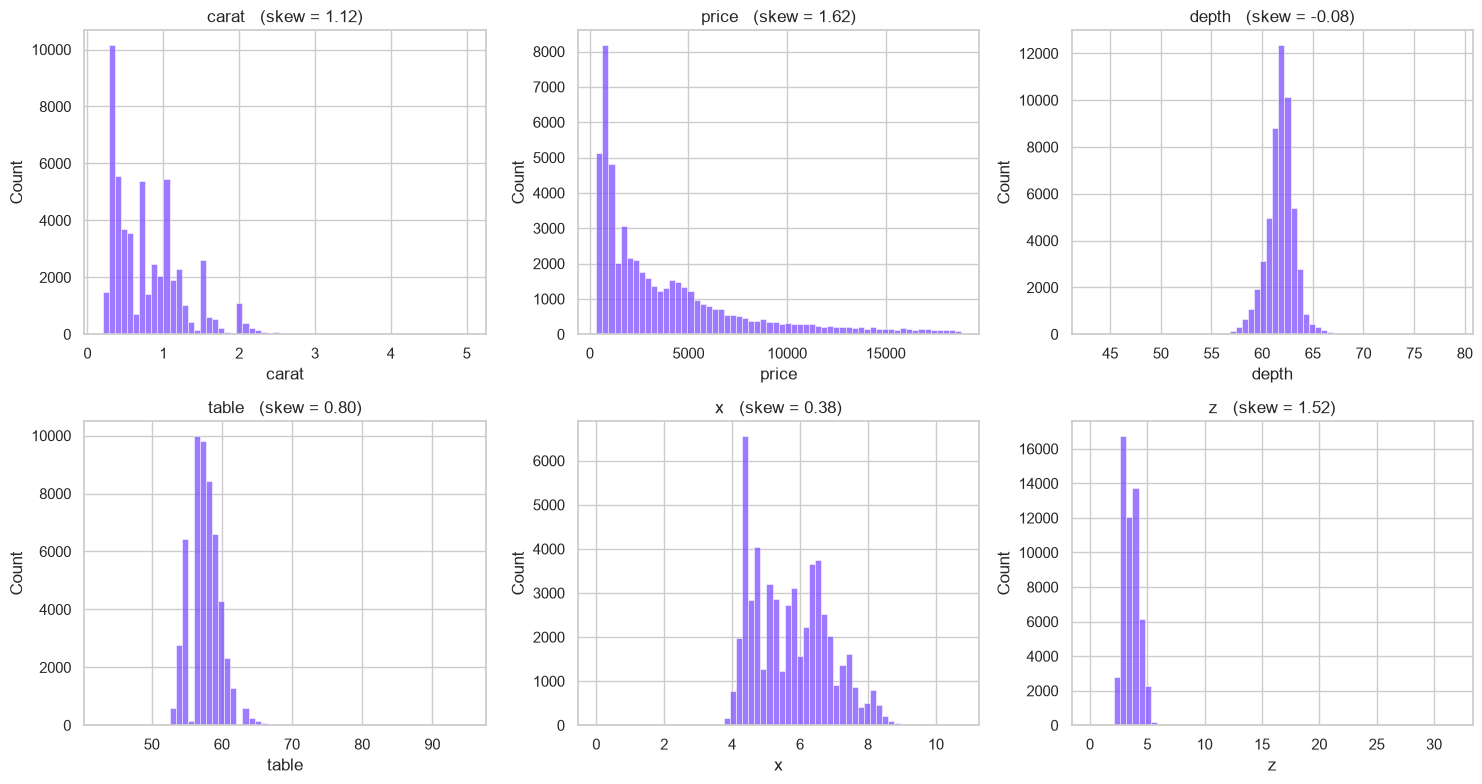

In [5]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
for a, col in zip(ax.flat, ["carat", "price", "depth", "table", "x", "z"]):
    sns.histplot(df[col], bins=60, ax=a, color=PALETTE["primary"])
    a.set_title(f"{col}   (skew = {df[col].skew():.2f})")
plt.tight_layout(); plt.show()

**`price` and `carat` are both heavily right-skewed** — a long tail of a few very expensive,
very large stones. This is the single most consequential fact in the whole EDA, and it drives
a decision later: in notebook 04 we predict **log(price)**, not price. A neural net minimising
squared error on raw price would spend nearly all its effort on the handful of $18,000 stones
and neglect the thousands of $1,000 ones.

## Categorical distributions — and the class imbalance problem

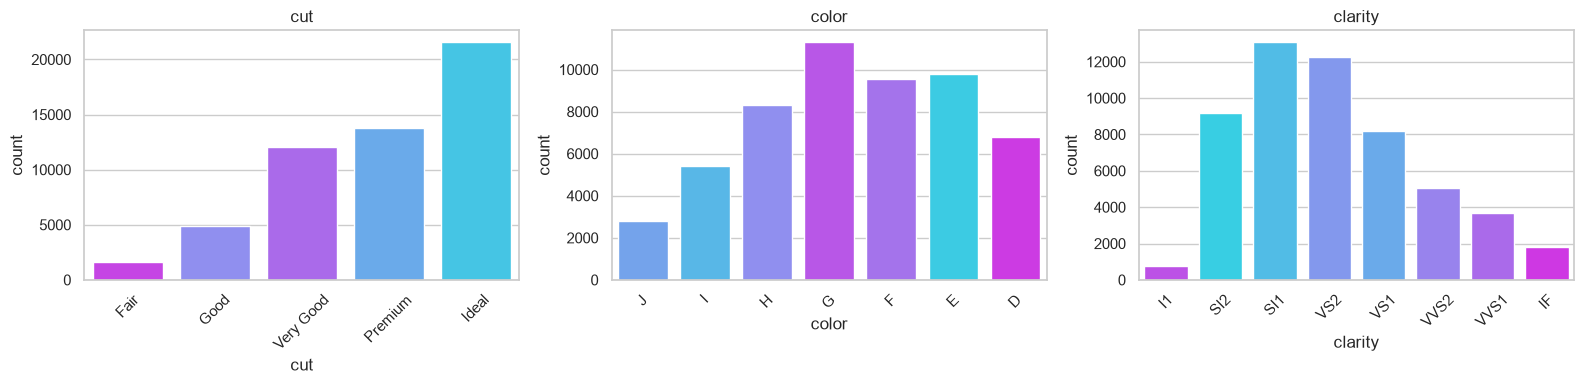

Clarity class balance (our classification target):
clarity
SI1     24.2
VS2     22.7
SI2     17.0
VS1     15.1
VVS2     9.4
VVS1     6.8
IF       3.3
I1       1.4


In [23]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, (col, order) in zip(ax, [("cut", CUT_ORDER), ("color", COLOR_ORDER), ("clarity", CLARITY_ORDER)]):
    sns.countplot(data=df, x=col, order=order, ax=a, hue=col, palette="cool", legend=False)
    a.set_title(col); a.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

print("Clarity class balance (our classification target):")
print(df["clarity"].value_counts(normalize=True).mul(100).round(1).to_string())

**This is a warning, and you should read it now rather than be confused later.**

Clarity is badly imbalanced — SI1 and VS2 dominate; I1 is barely present. A classifier that
ignored every input and always guessed "SI1" would already score around 24% accuracy. That is
the **baseline you must beat**, and it is why we report **macro F1** alongside accuracy in
notebook 03: accuracy rewards a model for getting the crowded classes right, and macro F1
does not let it off the hook for ignoring the rare ones.

## Correlations — including one genuinely counterintuitive result

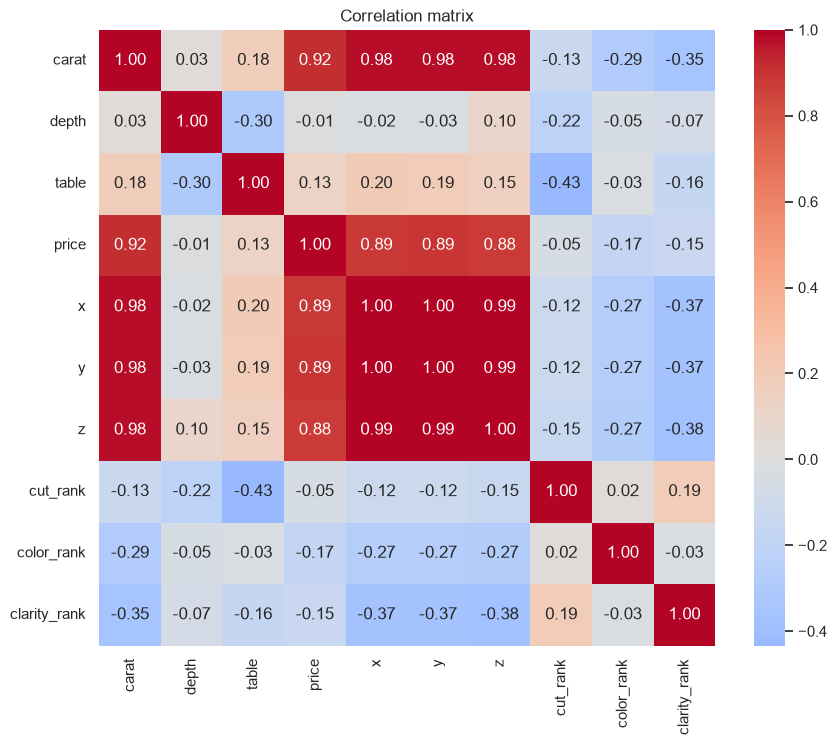

What correlates with price:
price           1.000
carat           0.922
y               0.889
x               0.887
z               0.882
table           0.126
depth          -0.011
cut_rank       -0.052
clarity_rank   -0.146
color_rank     -0.172


In [24]:
from src.data_prep import clean, engineer, encode
work = encode(engineer(clean(df, verbose=False)))

num = ["carat", "depth", "table", "price", "x", "y", "z",
       "cut_rank", "color_rank", "clarity_rank"]
corr = work[num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix"); plt.show()

print("What correlates with price:")
print(corr["price"].sort_values(ascending=False).round(3).to_string())

### Read this carefully — it is the most interesting finding in the dataset

- **carat, x, y, z all correlate with price above 0.85.** Size dominates. Unsurprising.
- **x, y, z correlate with each other above 0.97.** They are three views of one property.
  This is *multicollinearity*: three columns carrying one column's worth of information.
- **`clarity_rank` correlates with price NEGATIVELY (about −0.15).** And `color_rank` too.

That last one looks broken. Better clarity should mean *higher* price, shouldn't it?

It isn't broken — it's **selection bias in the real world**, and it is a genuinely important
lesson. Large diamonds are almost always slightly flawed, because a big flawless crystal is
astronomically rare. So the high-carat, high-price stones in this dataset skew toward *lower*
clarity grades. Carat's effect on price is so overwhelming that it swamps clarity's, and
because carat and clarity are inversely related in the population, clarity ends up with a
negative raw correlation to price.

**Hold clarity constant and price still rises with carat. Hold carat constant and price still
rises with clarity.** The negative correlation is an artefact of the two being confounded.

This is why a correlation matrix is a *starting* point, never a conclusion — and it is exactly
the kind of thing a model that sees both variables at once can untangle, but a naive
single-variable reading cannot.

In [25]:
# [Proof: hold carat roughly constant, and clarity's real effect reappears.]
band = work[work["carat"].between(0.95, 1.05)]
print("Diamonds between 0.95 and 1.05 carat — mean price by clarity:\n")
print(band.groupby("clarity")["price"].agg(["mean", "count"])
        .reindex(CLARITY_ORDER).dropna().round(0).to_string())

Diamonds between 0.95 and 1.05 carat — mean price by clarity:

            mean  count
clarity                
I1        2693.0    158
SI2       4133.0   1703
SI1       4877.0   1827
VS2       5951.0   1285
VS1       6598.0    698
VVS2      8268.0    392
VVS1      9034.0    142
IF       10799.0     97


Within a fixed carat band, price climbs steadily with clarity, exactly as it should. The confound is broken and the true relationship shows through.

## Trends

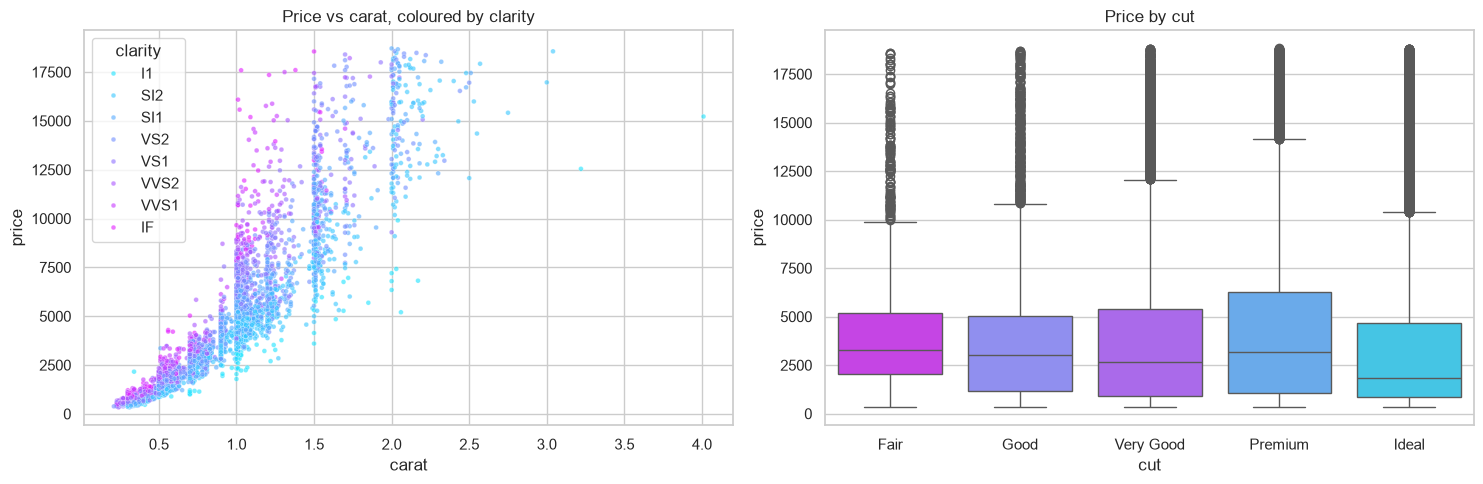

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sample = work.sample(5000, random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x="carat", y="price", hue="clarity",
                hue_order=CLARITY_ORDER, palette="cool", s=12, alpha=.6, ax=ax[0])
ax[0].set_title("Price vs carat, coloured by clarity")

sns.boxplot(
    data=work, x="cut", y="price",
    order=CUT_ORDER, hue="cut", palette="cool", ax=ax[1]
)
leg = ax[1].get_legend()
if leg is not None:
    leg.remove()

ax[1].set_title("Price by cut")
plt.tight_layout(); plt.show()

The left plot shows the **fanning** shape: price rises with carat, but the *spread* rises too —
another sign that the relationship is multiplicative, and more support for modelling log(price).
You can also see clarity separating into bands within each carat slice.

The right plot is a nice trap. **Fair-cut diamonds show a *higher* median price than Ideal.**
Same confound as before: Fair-cut stones tend to be large (a cutter accepts a poor cut to retain
weight from a big rough crystal). It is carat talking, not cut.